In [12]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

import matplotlib.pyplot as plt
import seaborn as sns
from calendar import month_name
from windrose import WindroseAxes
from scipy.stats import f_oneway

In [3]:
df_benin = pd.read_csv('../data/benin_clean.csv')
df_togo = pd.read_csv('../data/togo-dapaong_qc_clean.csv')
df_sierraleone = pd.read_csv('../data/sierraleone-bumbuna_clean.csv')

In [4]:
#  add a country column to each for easier plotting
df_benin['Country'] = 'Benin'
df_togo['Country'] = 'Togo'
df_sierraleone['Country'] = 'Sierra Leone'

In [5]:
# Combine into a single DataFrame
df_all = pd.concat([df_benin, df_togo, df_sierraleone], ignore_index=True)


### Metric Comparison


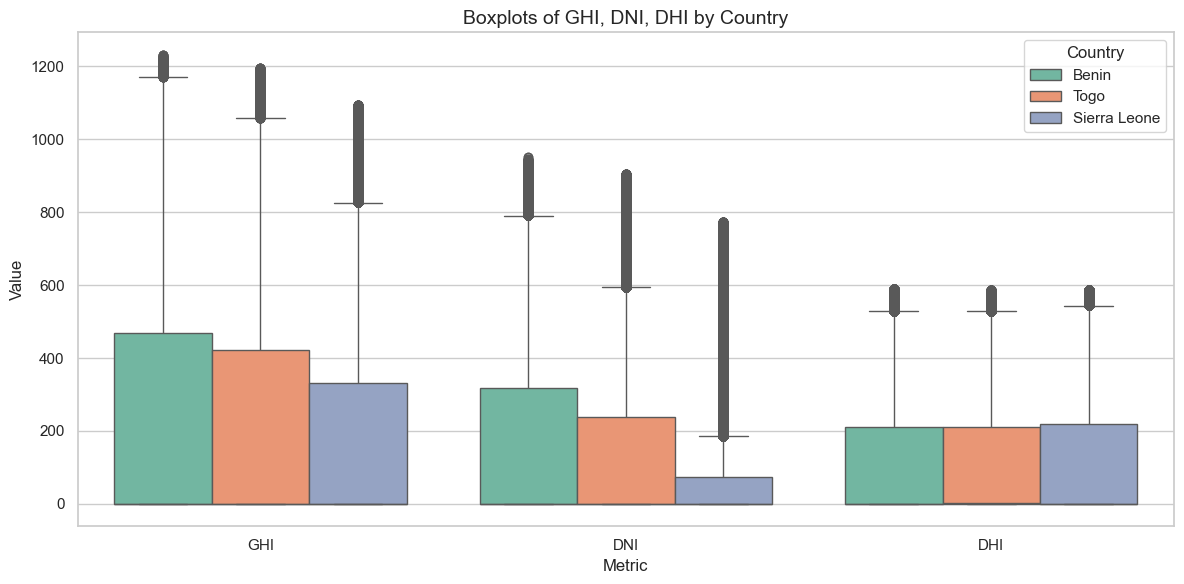

In [7]:

# Keep only the relevant columns
cols = ["Country", "GHI", "DNI", "DHI"]
df_plot = df_all[cols].melt(id_vars="Country", var_name="Metric", value_name="Value")

# Set style
sns.set(style="whitegrid", palette="Set2")

# Plot boxplots side-by-side for each metric, colored by country
plt.figure(figsize=(12, 6))
sns.boxplot(x="Metric", y="Value", hue="Country", data=df_plot)
plt.title("Boxplots of GHI, DNI, DHI by Country", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("Value")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

In [8]:
summary = df_all.groupby('Country')[metrics].agg(['mean', 'median', 'std']).round(2)
summary


GHI                    DNI                    DHI         \
                mean median     std    mean median     std    mean median   
Country                                                                     
Benin         237.48    0.6  327.17  167.14    0.0  261.94  113.17    0.4   
Sierra Leone  187.21    0.0  277.02  104.21    0.0  200.82  110.50    0.0   
Togo          225.03    0.5  316.45  147.97    0.0  247.68  112.78    1.5   

                      
                 std  
Country               
Benin         151.66  
Sierra Leone  151.44  
Togo          151.57


### Statistical Testing 


In [13]:

# Extract GHI for each country
ghi_benin = df_benin['GHI']
ghi_togo = df_togo['GHI']
ghi_sierra = df_sierraleone['GHI']

# One-way ANOVA
anova_result = f_oneway(ghi_benin, ghi_togo, ghi_sierra)
print("ANOVA F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)


ANOVA F-statistic: 3705.219565834379
p-value: 0.0



### Key Observations



#### Benin shows the highest median and mean GHI among the three countries, along with greater variability, indicating strong but fluctuating solar potential.

#### Sierra Leone records the lowest GHI and DNI values, suggesting comparatively weaker direct solar irradiance but similar diffuse radiation levels to the others.

#### The ANOVA results (p < 0.05) confirm that the differences in mean GHI across countries are statistically significant, with Benin standing out as the most solar-rich location.


### Visual Summary 


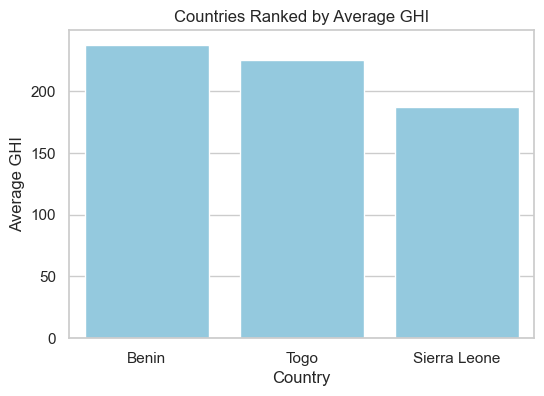

In [15]:

avg_ghi = df_all.groupby('Country')['GHI'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(
    x=avg_ghi.index, 
    y=avg_ghi.values, 
    color='skyblue'  # single color instead of palette
)
plt.ylabel('Average GHI')
plt.title('Countries Ranked by Average GHI')
plt.show()
